## Model 001 Review Checklist (Return Plan)

- [ ] **1) Metric checkpoint (train vs val)**
  - Compute `RMSE`, `MAE`, `R²` on train + val.
  - Put in one table with a `gap = val - train` column.

- [ ] **2) Compare against dumb baselines**
  - Bring in val metrics from `model_000_dumb`.
  - Create one table: `all_zero`, `train_mean`, `empirical_random`, `linreg`.
  - Confirm linreg materially beats simple baselines.

- [ ] **3) Residual diagnostics**
  - Keep `predicted vs residual` scatter.
  - Add residual histogram.
  - Add residual quantiles (`p50/p90/p95/p99`).
  - Add residual spread by prediction bins (std or IQR).

- [ ] **4) Fit-shape check**
  - Plot `actual vs predicted` with `y=x`.
  - Repeat on `log1p(votes_helpful)` view.

- [ ] **5) Error-slice review**
  - Inspect top-N rows by absolute residual.
  - Check for patterns by `app_name` / extreme targets / data oddities.

- [ ] **6) Coefficient sanity**
  - Show coefficients sorted by absolute value.
  - Check sign plausibility and very large coefficients.

- [ ] **7) Leakage/feature audit**
  - Reconfirm only allowed features are in training matrix.
  - Ensure no post-outcome columns leaked in.

- [ ] **8) Decision note**
  - Write 3-5 bullets:
    - Is linreg acceptable baseline?
    - Main failure mode
    - Next model to try

## Section Index

1. Setup and imports
2. Data loading
3. Metric helpers
4. Data sanity checks
5. Modeling and evaluation
6. Residual/error diagnostics

## 1) Setup and Imports

In [1]:
import sys
from pathlib import Path

import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Repo `src/` on path (use `pip install -e .` from repo root if you prefer)
_src = Path("../../src").resolve()
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from sklearn.linear_model import LinearRegression

from steam_review_ml.evaluation import regression_metrics


## 2) Data Loading

In [2]:
# load training data as pandas dataframe
df_train = pd.read_parquet('../../data/processed/steam_reviews_cleaned_english_train_norm.parquet')
df_val = pd.read_parquet('../../data/processed/steam_reviews_cleaned_english_val_norm.parquet')

## 3) Metric Helpers

In [3]:
# Metrics: see `steam_review_ml.evaluation.regression_metrics` (shared with model_000 dumb baselines).


## 4) Data Sanity Checks

In [4]:
df_train.head()

,review_id,app_id,app_name,author.steamid,review,recommended,votes_helpful,author.num_games_owned,author.num_reviews,author.playtime_last_two_weeks,...,author.last_played,is_helpful,review_length_chars,review_word_count,_norm_votes_helpful,_norm_author__playtime_last_two_weeks,_norm_author__playtime_at_review,_norm_author__num_games_owned,_norm_author__num_reviews,_norm_review_word_count
0,85184605,292030,The Witcher 3: Wild Hunt,76561199054755373,"One of the best RPG's of all time, worthy of a...",1,0,5,3,3200.0,...,1.611384e+09,0,59,12,0.0,8.071219,8.617039,1.791759,1.386294,2.564949
1,85184171,292030,The Witcher 3: Wild Hunt,76561198170193529,"good story, good graphics. lots to do.",1,0,11,1,823.0,...,1.611379e+09,0,38,7,0.0,6.714171,6.714171,2.484907,0.693147,2.079442
2,85184064,292030,The Witcher 3: Wild Hunt,76561198119302812,"dis gud,",1,0,27,2,3398.0,...,1.611352e+09,0,8,2,0.0,8.131237,8.341172,3.332205,1.098612,1.098612
3,85180436,292030,The Witcher 3: Wild Hunt,76561198065591528,favorite game of all time cant wait for the Ne...,1,0,33,1,177.0,...,1.611219e+09,0,59,11,0.0,5.181784,10.057495,3.526361,0.693147,2.484907
4,85179753,292030,The Witcher 3: Wild Hunt,76561198996835044,Why wouldn't you get this,1,0,131,2,2004.0,...,1.611371e+09,0,25,5,0.0,7.603399,9.054622,4.882802,1.098612,1.791759


In [5]:
df_train.columns

Index(['review_id', 'app_id', 'app_name', 'author.steamid', 'review',
       'recommended', 'votes_helpful', 'author.num_games_owned',
       'author.num_reviews', 'author.playtime_last_two_weeks',
       'author.playtime_at_review', 'steam_purchase', 'received_for_free',
       'written_during_early_access', 'timestamp_created',
       'author.last_played', 'is_helpful', 'review_length_chars',
       'review_word_count', '_norm_votes_helpful',
       '_norm_author__playtime_last_two_weeks',
       '_norm_author__playtime_at_review', '_norm_author__num_games_owned',
       '_norm_author__num_reviews', '_norm_review_word_count'],
      dtype='str')

# 5) Modeling and Evaluation

## Full Dataset Model

In [6]:
# instantiate linear regression model
linreg = LinearRegression()

training_cols = [
    'author.num_games_owned',
    'author.num_reviews', 'author.playtime_last_two_weeks',
    'author.playtime_at_review', 'steam_purchase', 'received_for_free',
    'written_during_early_access', 'timestamp_created',
    'author.last_played', 'review_length_chars',
    'review_word_count'
]
linreg.fit(
    X=df_train[training_cols],
    y=df_train['votes_helpful']
)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
# predict helpful votes
df_train["votes_helpful_pred"] = linreg.predict(df_train[training_cols])
df_val["votes_helpful_pred"] = linreg.predict(df_val[training_cols])

SEED = 2026
rng = np.random.default_rng(SEED)

vt = df_train["votes_helpful"].astype(float)
mean_helpful = float(vt.mean())
value_probs = vt.value_counts(normalize=True).sort_index()
emp_values = value_probs.index.to_numpy()
emp_probs = value_probs.to_numpy()

pred_rows = []

# baselines (same idea as model_000_dumb_002)
z_tr = np.zeros(len(df_train), dtype=float)
z_va = np.zeros(len(df_val), dtype=float)
pred_rows.append(("all_zero", z_tr, z_va))

m_tr = np.full(len(df_train), mean_helpful, dtype=float)
m_va = np.full(len(df_val), mean_helpful, dtype=float)
pred_rows.append(("train_mean", m_tr, m_va))

e_tr = rng.choice(emp_values, size=len(df_train), p=emp_probs).astype(float)
e_va = rng.choice(emp_values, size=len(df_val), p=emp_probs).astype(float)
pred_rows.append(("empirical_random", e_tr, e_va))

lin_tr = df_train["votes_helpful_pred"].to_numpy(dtype=float)
lin_va = df_val["votes_helpful_pred"].to_numpy(dtype=float)
pred_rows.append(("linreg", lin_tr, lin_va))

y_tr = df_train["votes_helpful"].to_numpy(dtype=float)
y_va = df_val["votes_helpful"].to_numpy(dtype=float)

table_rows = []
for name, p_tr, p_va in pred_rows:
    tr = regression_metrics(y_tr, p_tr)
    va = regression_metrics(y_va, p_va)
    row = {"model": name}
    for k, v in tr.items():
        row[f"train_{k}"] = v
    for k, v in va.items():
        row[f"val_{k}"] = v
    table_rows.append(row)

metrics_compare = pd.DataFrame(table_rows)
numeric_cols = [c for c in metrics_compare.columns if c != "model"]
for c in numeric_cols:
    if c.startswith("val_"):
        k = c.replace("val_", "", 1)
        tc = f"train_{k}"
        if tc in metrics_compare.columns:
            metrics_compare[f"gap_{k}"] = metrics_compare[c] - metrics_compare[tc]

metrics_compare


/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/nump

,model,train_mae,train_mse,train_rmse,train_r2,train_mape_pct,train_spearman_rho,val_mae,val_mse,val_rmse,val_r2,val_mape_pct,val_spearman_rho,gap_mae,gap_mse,gap_rmse,gap_r2,gap_mape_pct,gap_spearman_rho
0,all_zero,2.011896,2161.199622,46.488704,-0.001876,2.988793e+01,NaN,2.025414,2528.213436,50.281343,-1.625247e-03,2.987633e+01,NaN,0.013518,367.013814,3.792639,2.511753e-04,-1.159781e-02,NaN
1,train_mean,3.173952,2157.151895,46.445149,0.000000,1.410582e+10,NaN,3.187729,2524.111315,50.240535,-7.239525e-08,1.410816e+10,NaN,0.013777,366.959420,3.795385,-7.239525e-08,2.333359e+06,NaN
2,empirical_random,3.759418,4177.886788,64.636575,-0.936761,1.395824e+10,-0.000525,3.805166,4953.986370,70.384561,-9.626657e-01,1.442237e+10,-0.000654,0.045747,776.099582,5.747986,-2.590512e-02,4.641238e+08,-0.000129
3,linreg,3.092562,2148.115925,46.347772,0.004189,1.136088e+10,0.283246,3.107099,2515.885089,50.158599,3.258986e-03,1.137728e+10,0.282147,0.014536,367.769163,3.810828,-9.298561e-04,1.640590e+07,-0.001099


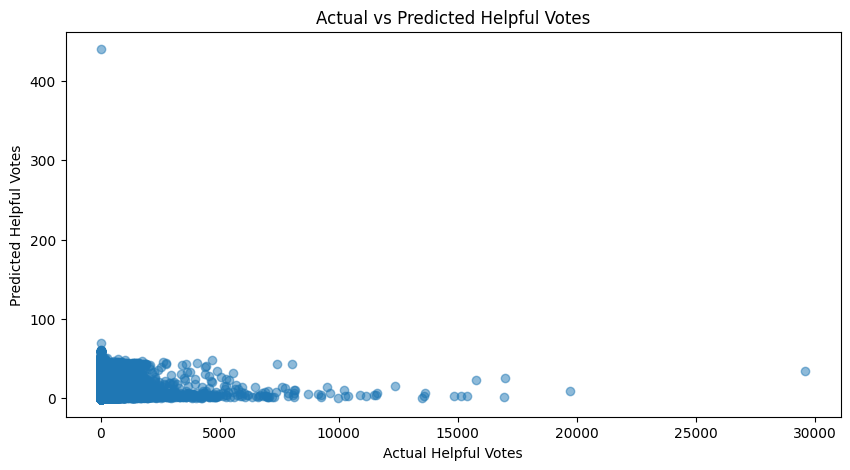

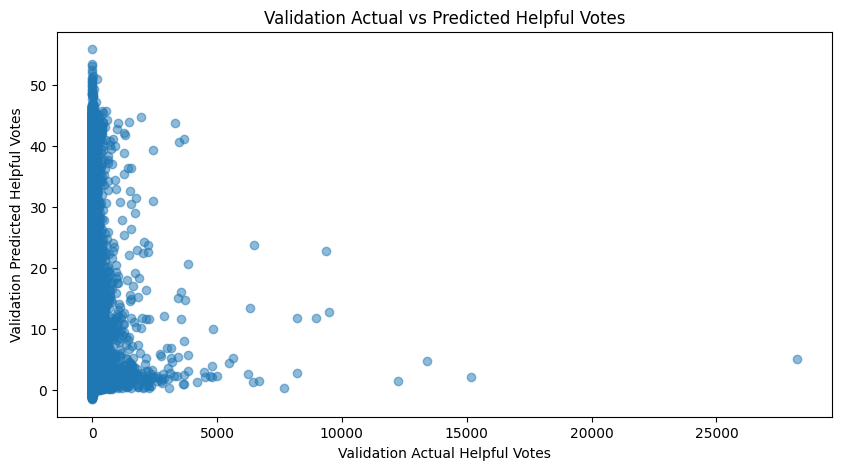

In [8]:
# plot actual vs predicted helpful votes
plt.figure(figsize=(10, 5))
plt.scatter(df_train["votes_helpful"], df_train["votes_helpful_pred"], alpha=0.5)
plt.xlabel("Actual Helpful Votes")
plt.ylabel("Predicted Helpful Votes")
plt.title("Actual vs Predicted Helpful Votes")
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(df_val["votes_helpful"], df_val["votes_helpful_pred"], alpha=0.5)
plt.xlabel("Validation Actual Helpful Votes")
plt.ylabel("Validation Predicted Helpful Votes")
plt.title("Validation Actual vs Predicted Helpful Votes")
plt.show()


### Residual and Error Diagnostics

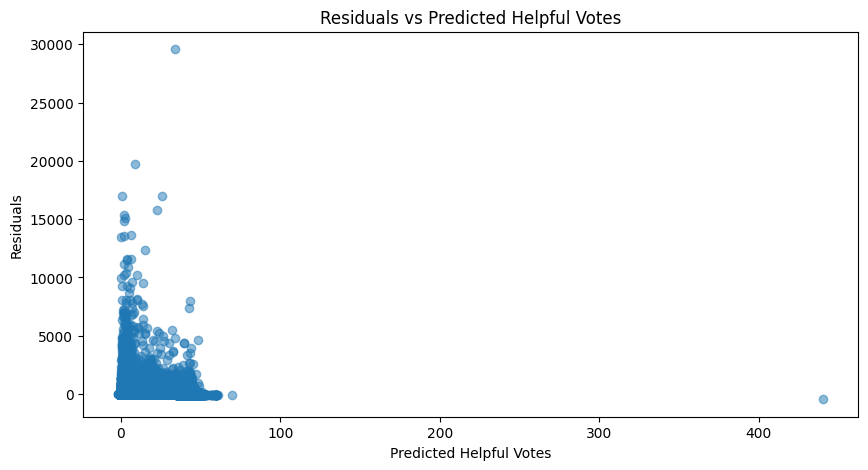

In [9]:
# plot residuals
plt.figure(figsize=(10, 5))
plt.scatter(df_train['votes_helpful_pred'], df_train['votes_helpful'] - df_train['votes_helpful_pred'], alpha=0.5)
plt.xlabel('Predicted Helpful Votes')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Helpful Votes')
plt.show()

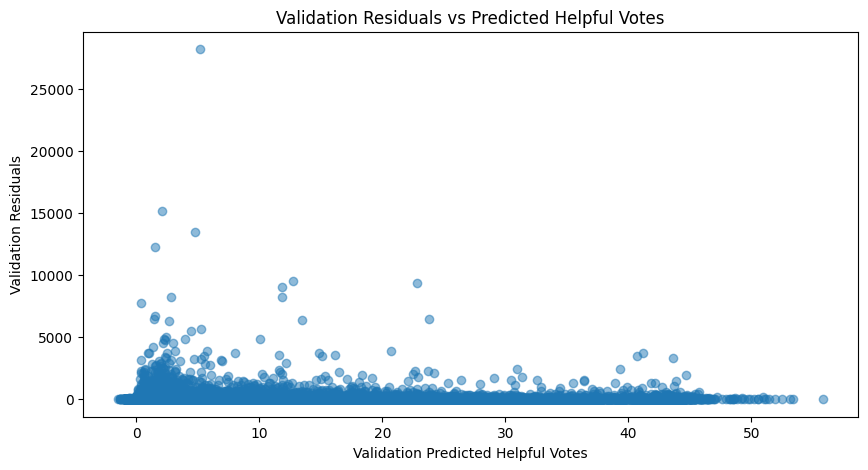

In [10]:
#plot val residuals
plt.figure(figsize=(10, 5))
plt.scatter(df_val['votes_helpful_pred'], df_val['votes_helpful'] - df_val['votes_helpful_pred'], alpha=0.5)
plt.xlabel('Validation Predicted Helpful Votes')
plt.ylabel('Validation Residuals')
plt.title('Validation Residuals vs Predicted Helpful Votes')
plt.show()

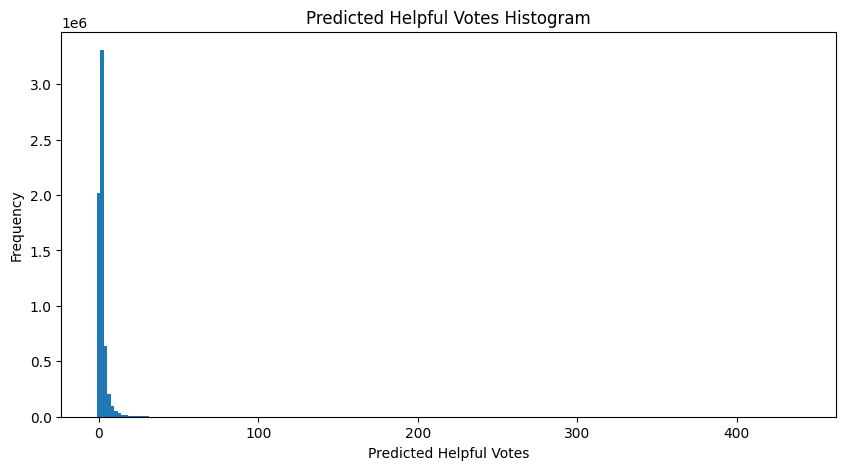

In [11]:
# plot predicted helpful votes from training data as a histogram
plt.figure(figsize=(10, 5))
plt.hist(df_train['votes_helpful_pred'], bins=200)
plt.xlabel('Predicted Helpful Votes')
plt.ylabel('Frequency')
plt.title('Predicted Helpful Votes Histogram')
plt.show()

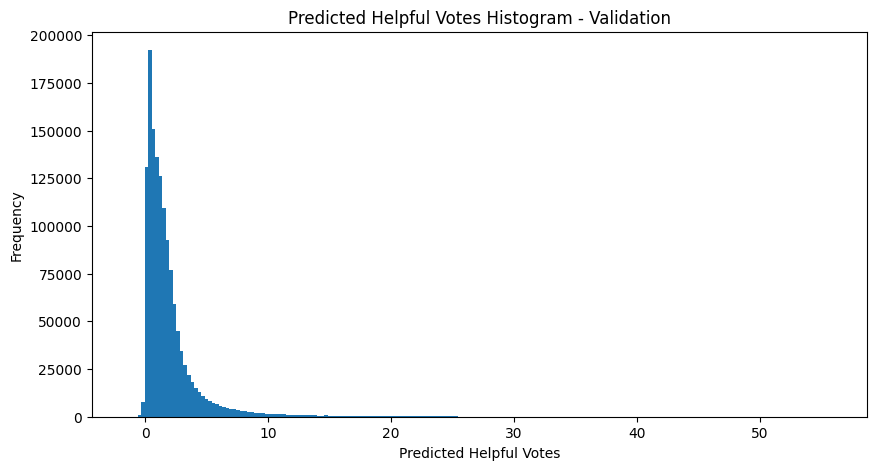

In [12]:
# plot predicted helpful votes from training data as a histogram
plt.figure(figsize=(10, 5))
plt.hist(df_val['votes_helpful_pred'], bins=200)
plt.xlabel('Predicted Helpful Votes')
plt.ylabel('Frequency')
plt.title('Predicted Helpful Votes Histogram - Validation')
plt.show()

In [13]:
import plotly.graph_objects as go

# Create a bar plot of feature importances using Plotly
fig = go.Figure()

fig.add_trace(go.Bar(
    x=training_cols,
    y=linreg.coef_,
    marker_color='royalblue'
))

fig.update_layout(
    title='Most Important Features',
    xaxis_title='Features',
    yaxis_title='Coefficients',
    xaxis_tickangle=45,
    xaxis_tickfont=dict(size=10),
    margin=dict(b=150),  # Provide extra bottom margin for rotated labels
    height=500,
    width=1000
)

fig.show()

## Only using `author.num_reviews`, `review_length_chars`, and `review_word_count`

### Residual and Error Diagnostics